In [273]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian
from psyduck.tensors import get_R_tensor, voigt_to_tensor

In [274]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55 * 1e6 # Nuclear Zeeman splitting (MHz/T)

In [275]:
nmr = np.array([[5172791, 5192239, 5211740, 5231304, 5250923, 5270595, 5290345], [5160688, 5168255, 5176257, 5184657, 5193455, 5202655, 5212240], [5193539, 5182071, 5171162, 5160824, 5151057, 5141862, 5133238],
                [5059454, 5031774, 5004403, 4977343, 4950602, 4924210, 4898143]])
thetas = np.array([0, 22.5, 45, 67.5])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
f_ner1_measured = np.array([
    [1/695269,  1/794668, 1/1435812, 0, 1/1426646,  1/804481,  1/694418],
    [ 1/686240, 1/781800, 1/1392608, 0, 1/1432536,  1/794038,  1/684887],
    [ 1/724982, 1/820604, 1/1461844, 0, 1/1471447,  1/819658,  1/702738]
]) * 1e9
f_ner2_measured = 1/np.array([
    [6199939,  4560535, 3957246, 3999002, 4549282,  6302998],
    [5964587, 4554291, 3907868, 3985586, 4576766, 6594215],
     [3042804, 2118640, 1842177, 1828053, 2099015, 3039585]
]) * 1e9

In [276]:
nmr.shape

(4, 7)

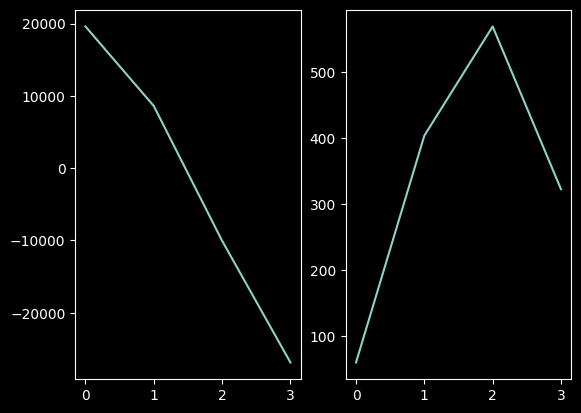

In [277]:
fig, ax = plt.subplots(1,2)
ax[0].plot(fq_1_measured)
ax[1].plot(fq_2_measured)

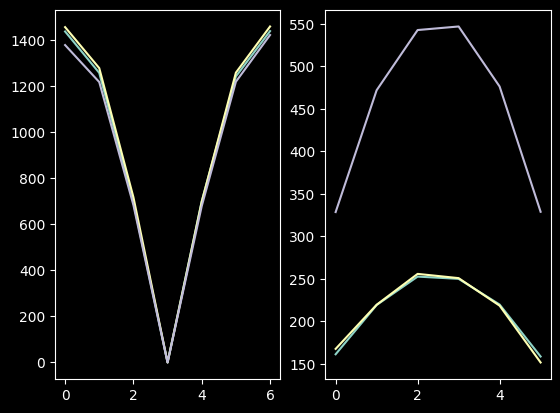

In [278]:
fig, ax = plt.subplots(1,2)
ax[0].plot(f_ner1_measured.T)
ax[1].plot(f_ner2_measured.T)

In [299]:
B0 = np.mean(nmr[0])/GAMMA_NUCLEAR

def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta)
    return H_zeeman + H_q

# R-tensor (Si, (110) orientation): maps AC field [Ex, Ey, Ez] → EFG Voigt vector
_R_tensor = get_R_tensor()   # (6, 3)

def _drive_in_eigenbasis(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z):
    """Drive Hamiltonian (from AC field E_ac) in the energy eigenbasis of H_ion."""
    E_ac       = np.array([E_x, E_y, E_z])
    EFG_tensor = voigt_to_tensor(_R_tensor @ E_ac)
    H_drive    = quadrupole_hamiltonian_from_Vab(I_SPIN, EFG_tensor, Q_N).full()
    H_ion      = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    _, evecs   = H_ion.eigenstates()
    U          = np.column_stack([v.full().flatten() for v in evecs])
    return U.conj().T @ H_drive @ U

def ner1(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z), 1))

def ner2(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, scale=1.0):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, scale*E_x, scale*E_y, scale*E_z), 2))

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz).eigenstates()[0]
    return np.flip(np.diff(evals)).flatten()


In [300]:
B0

np.float64(0.942598120978121)

In [301]:

def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    return np.vstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
    ])

params = Parameters()
params.add('Vxx', value=-4, min=-5,  max=5)
params.add('Vyy', value=1,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)
# params.add('scale', value=0, min=0, max=0.1)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.595       -5        5  0.05225     True     None     None
Vxy     1.319      -20       20  0.05469     True     None     None
Vxz    0.3788       -5       20  0.04196     True     None     None
Vyy    -0.966       -5        5  0.06512     True     None     None
Vyz     1.355       -5       20  0.04369     True     None     None
Vzz    -1.629     -inf      inf  0.02473    False - Vxx - Vyy     None


In [302]:
# def residual(params):
#     p = params.valuesdict()
#     nmr_freqs = nmr_frequencies(**p).flatten()
#     ner1_rabi = ner1(**p).flatten()
#     ner2_rabi = ner2(**p).flatten()
#     fq1 = np.mean(np.diff(nmr_freqs))
#     fq2 = np.mean(np.diff(np.diff(nmr_freqs)))
#     res = np.hstack([
#         np.abs(fq_1_measured - fq1)**2 / np.abs(np.max(fq_1_measured))**2,
#         np.abs(fq_2_measured - fq2)**2 / np.abs(np.max(fq_2_measured))**2,
#         np.abs(f_ner1_measured - ner1_rabi)**2 / np.abs(np.max(f_ner1_measured))**2,
#         np.abs(f_ner2_measured - ner2_rabi)**2 / np.abs(np.max(f_ner2_measured))**2,
#     ])
#     return res



In [303]:
result

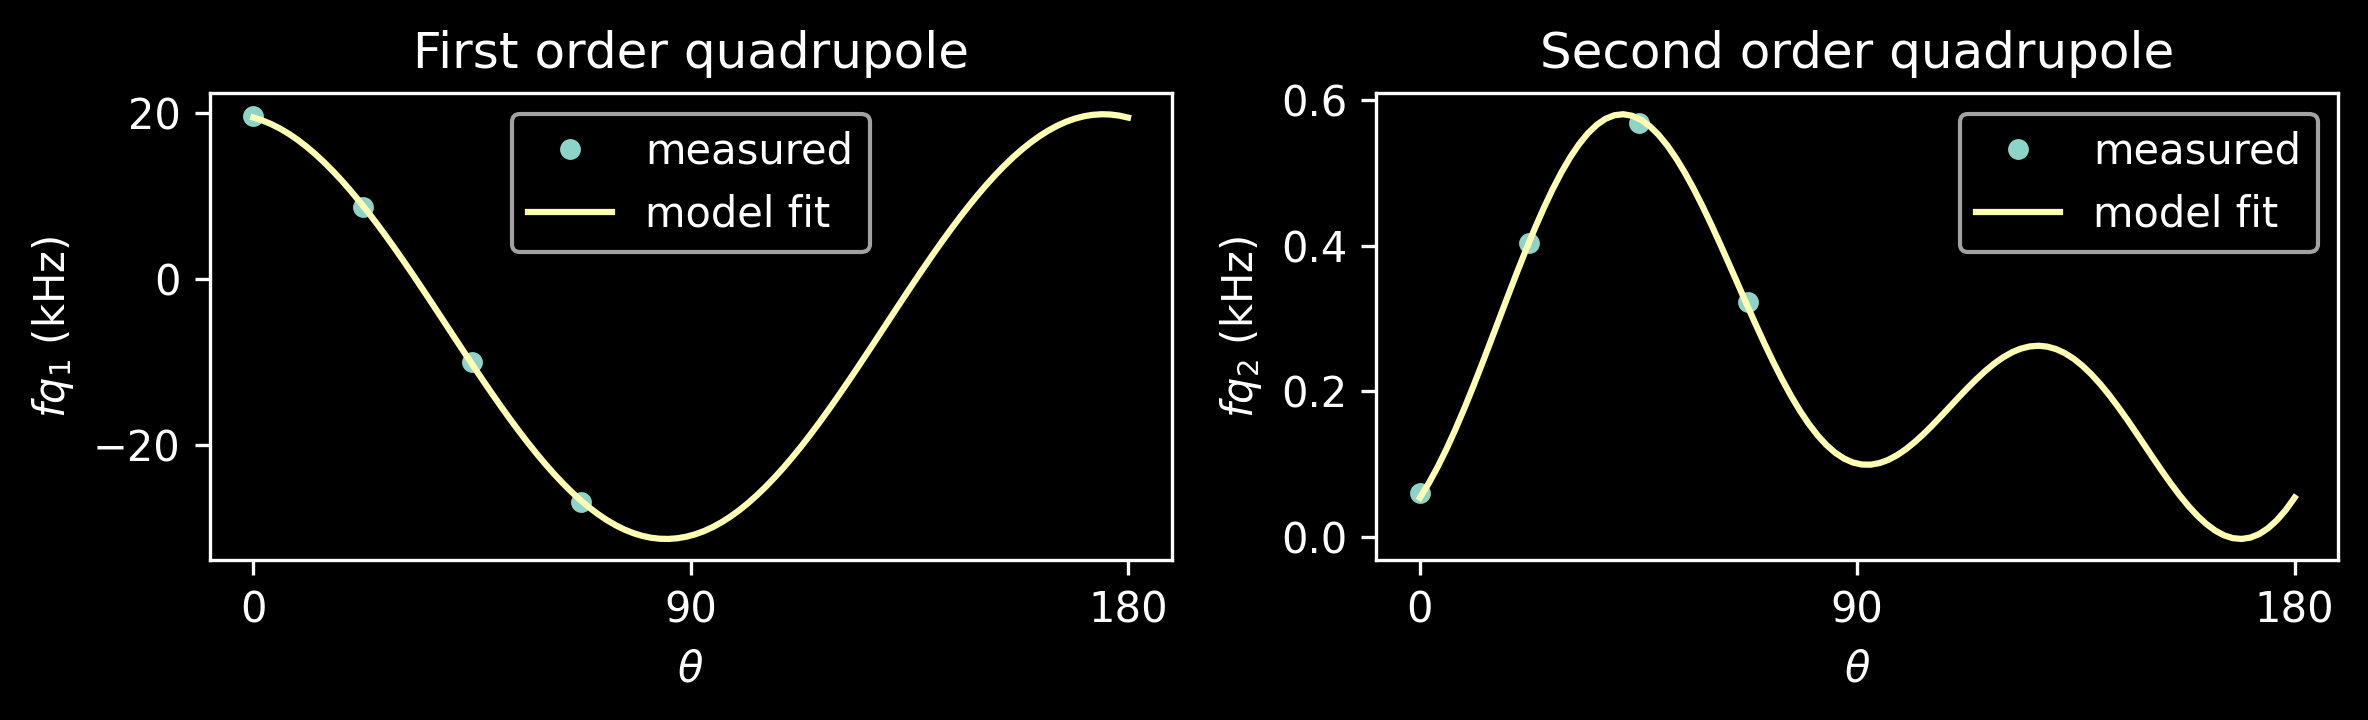

In [304]:
p = result.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)
fq1_arr = np.zeros(len(thetas_fit))
fq2_arr = np.zeros(len(thetas_fit))
for t, theta in enumerate(thetas_fit):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))

fig, ax = plt.subplots(1, 2, figsize=(8, 2.5), dpi=300)
ax[0].plot(thetas / np.pi * 180, fq_1_measured * 1e-3, '.', markersize=8, label='measured')
ax[0].plot(thetas_fit / np.pi * 180, fq1_arr * 1e-3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq_2_measured * 1e-3, '.', markersize=8, label='measured')
ax[1].plot(thetas_fit / np.pi * 180, fq2_arr * 1e-3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

In [309]:
p = result.params.valuesdict()
ner1_arr = np.zeros((len(thetas), 7))
ner2_arr = np.zeros((len(thetas), 6))
for t, theta in enumerate(thetas):
    ner1_arr[t] = ner1(theta, **p, E_x=100000, E_y=100000, E_z=100000)
    ner2_arr[t] = ner2(theta, **p, E_x=40000, E_y=40000, E_z=100000)

In [310]:
ner1_arr

array([[529.2821578 , 464.65325177, 261.81545835,   3.26595972,
        260.61206398, 469.78483709, 541.10393174],
       [479.57450809, 415.92246088, 230.0951891 ,  12.07616683,
        235.27595756, 416.14940398, 474.1258714 ],
       [539.95576804, 465.68968815, 254.34849356,  12.83559258,
        268.32460309, 468.81247406, 530.40821986],
       [475.36848524, 411.77290434, 225.9586377 ,   7.80244938,
        239.38299117, 420.49488279, 477.8409106 ]])

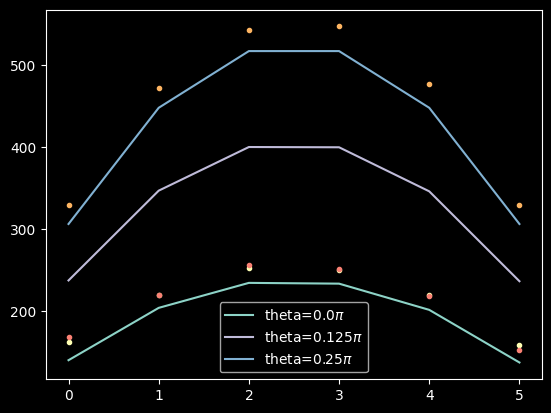

In [311]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner2_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner2_measured[t], '.')
plt.legend()

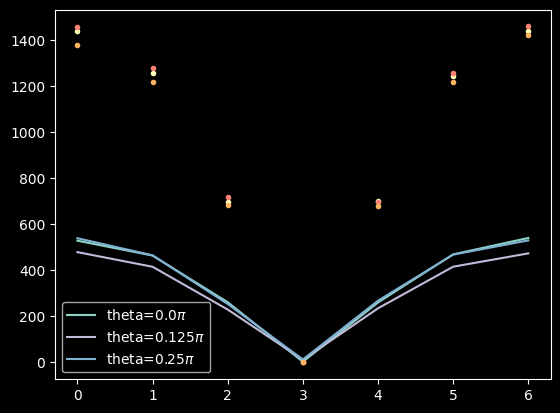

In [312]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner1_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner1_measured[t], '.')
plt.legend()

## Combined fit: fq_1, fq_2, and NER1 Rabi frequencies

In [313]:

_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p)
        ner2_arr[t]  = ner2(theta, **p)
    return np.hstack([
        (fq1_arr  - fq_1_measured)                    / np.max(np.abs(fq_1_measured)),
        (fq2_arr  - fq_2_measured)                    / np.max(np.abs(fq_2_measured)),
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# With the psyduck R-tensor (Si, 110 orientation):
#   Ez drives NER1 ({Iy,Iz})  →  scale_z ~ 270000 (estimated from NER1 outer transition ~1438 Hz)
#   Ey drives NER2 (Ix²-Iz²) →  scale_y ~ 52000  (estimated from NER2 outer transition ~161  Hz)
#   Ex drives NER2 ({Ix,Iy})  →  scale_x free, start small
params_full = result.params.copy()
params_full.add('E_x', value=0,       vary=False)
params_full.add('E_y', value=52000,   min=-1e7, max=1e7)
params_full.add('E_z', value=270000,  min=-1e7, max=1e7)

result_full = minimize(residual_full, params_full, method='leastsq')
result_full.params.pretty_print()


ValueError: operands could not be broadcast together with shapes (4,7) (3,7) 

In [200]:
result_full

In [297]:

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_full)
    ner2_fit[t]  = ner2(th, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(10, 10), dpi=150)

axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=f'$m={i-3}\\to{i-2}$')
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=7, ncol=2)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=f'$m={i-3}\\to{i-1}$')
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
axes[3].legend(fontsize=7, ncol=2)

for ax in axes:
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_xticks([0, 45, 90, 135, 180])
plt.tight_layout()


TypeError: ionized_hamiltonian() missing 6 required positional arguments: 'Vxx', 'Vyy', 'Vzz', 'Vxy', 'Vyz', and 'Vxz'

## just fit the scales, keep the tensor

In [316]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas)-1)
    fq2_arr   = np.zeros(len(thetas)-1)
    ner1_arr  = np.zeros((len(thetas)-1, 7))
    ner2_arr  = np.zeros((len(thetas)-1, 6))
    for t, theta in enumerate(thetas[:-1]):
        evals = ionized_hamiltonian(theta, **p_tensor, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p_tensor, **p)
        ner2_arr[t]  = ner2(theta, **p_tensor, **p)
    return np.hstack([
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('E_x', value=20,   min=-1e7, max=1e7)
params.add('E_y', value=1,  min=-1e7, max=1e7)
params.add('E_z', value=1,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)


result_full = minimize(residual_full, params, method='leastsq')
result_full


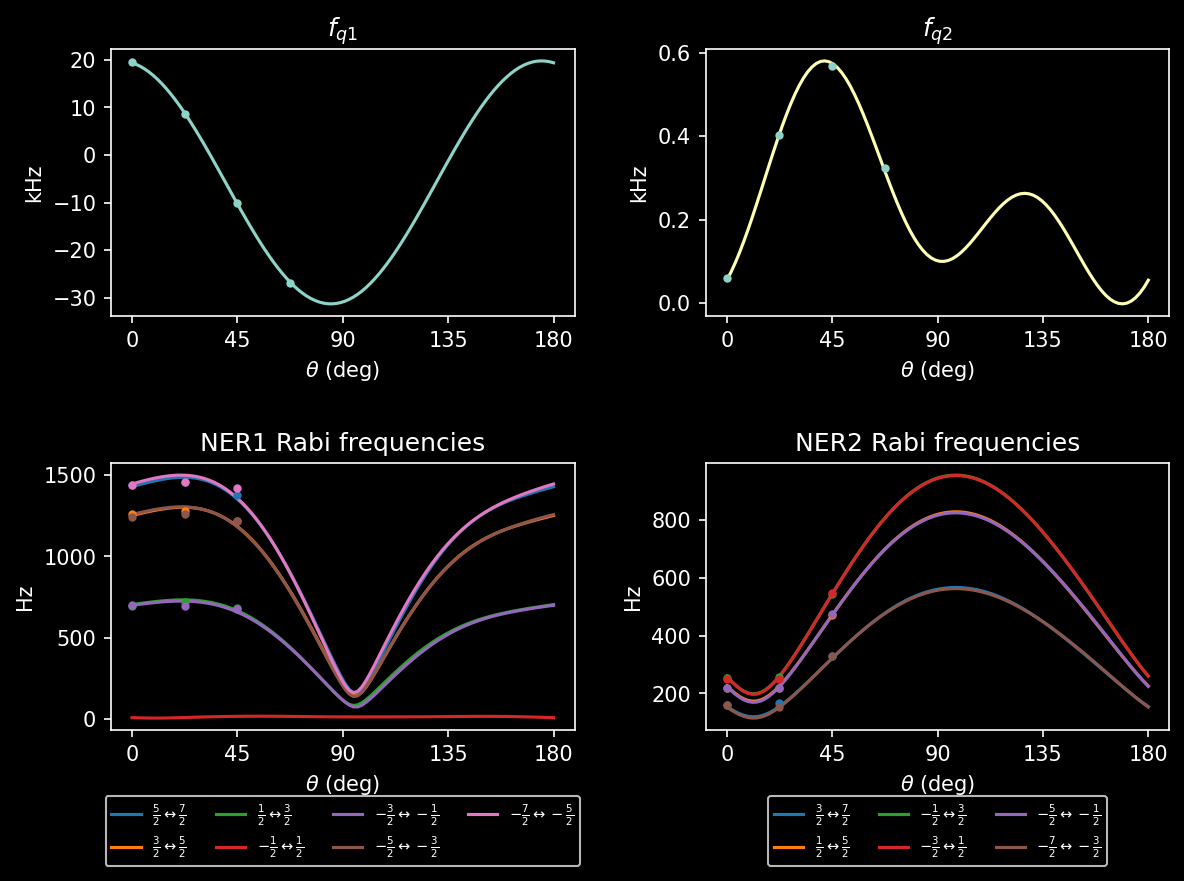

In [317]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_tensor, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_tensor, **p_full)
    ner2_fit[t]  = ner2(th, **p_tensor, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[:-1][mask_i], f_ner1_measured[mask_i, i], '.', color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=7, ncol=4, loc='upper center',
               bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg[:-1], f_ner2_measured[:, i], '.', color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
axes[3].legend(fontsize=7, ncol=3, loc='upper center',
               bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(hspace=0.55, bottom=0.18)
